In [1]:
!pip install catboost

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 99.2/99.2 MB 10.0 MB/s eta 0:00:00


In [2]:
import pandas as pd

# Load the Excel file into df_raw
df_raw = pd.read_excel('/content/Navi Mumbai 6 CAAQMS daily data.xlsx')

# Display the first few rows and information to confirm it's loaded correctly
print('df_raw loaded successfully:')
display(df_raw.head())
df_raw.info()

df_raw loaded successfully:


,Date,Month,Day,Year,Location,Regional Office,PM10,PM25,SO2,NO2,...,NOx,NO,OXYLENE,RG,SR,TEMP,TOLU,WD,WS,AQI
0,2022-11-28,11,28.0,2022,Belapur,Navi Mumbai,96.25,43.08,6.56,60.80,...,60.80,11.56,3.64,0.0,110.3,29.02,51.39,265.46,0.38,96.25
1,2022-11-29,11,29.0,2022,Belapur,Navi Mumbai,150.99,64.11,15.85,101.57,...,101.57,36.60,6.28,0.0,102.9,27.71,34.65,268.79,0.37,133.993333
2,2022-11-30,11,30.0,2022,Belapur,Navi Mumbai,188.77,90.66,11.91,86.60,...,86.60,32.22,7.05,0.0,92.9,29.06,35.27,263.84,0.31,202.2
3,2022-12-01,12,1.0,2022,Belapur,Navi Mumbai,169.99,87.43,13.69,65.93,...,65.93,32.63,5.59,0.4,99.7,28.54,27.57,262.29,0.31,191.433333
4,2022-12-02,12,2.0,2022,Belapur,Navi Mumbai,191.14,94.34,14.78,80.26,...,80.26,37.77,5.58,0.0,103.8,27.91,30.25,264.85,0.33,214.466667


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3931 entries, 0 to 3930
Data columns (total 27 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   Date             3931 non-null   datetime64[ns]
 1   Month            3931 non-null   int64         
 2   Day              3931 non-null   float64       
 3   Year             3931 non-null   int64         
 4   Location         3931 non-null   object        
 5   Regional Office  3931 non-null   object        
 6   PM10             3854 non-null   float64       
 7   PM25             3843 non-null   float64       
 8   SO2              3844 non-null   float64       
 9   NO2              3850 non-null   float64       
 10  CO               3780 non-null   object        
 11  O3               3845 non-null   float64       
 12  NH3              3783 non-null   float64       
 13  BENZ             3845 non-null   float64       
 14  ETHBENZ          3843 non-null   float64

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from catboost import CatBoostRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import time
import warnings
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer, SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.model_selection import train_test_split

warnings.filterwarnings('ignore')

# --- Helper Functions (Identical to before) ---

def compute_metrics(y_true, y_pred):
    """Calculates regression metrics."""
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)
    return {"rmse": rmse, "mae": mae, "r2": r2}

def run_and_record(model, name, results_list):
    """Trains, evaluates, and records metrics for a given model."""
    print(f"Running: {name}...")
    t0 = time.time()
    # Fit CatBoost model
    model.fit(X_train_scaled, y_train_scaled.ravel())
    train_time = time.time() - t0

    pred_scaled = model.predict(X_test_scaled)
    pred = scaler_y.inverse_transform(pred_scaled.reshape(-1,1)).flatten()

    # Calculate metrics
    metrics = compute_metrics(y_test, pred)

    result_data = {
        "name": name,
        "model": model,
        "metrics": metrics,
        "train_time": train_time
    }
    results_list.append(result_data)
    return result_data

# List to collect all results
all_results = []

# --- Data cleaning with MICE imputer (Identical to before) ---

try:
    df = df_raw.copy()
    print("Using df_raw from environment for preprocessing.")
except NameError:
    raise RuntimeError("df_raw not found. Please run the first cell to load the data.")

TARGET_COLUMN = 'AQI'
print(f"Using target column: {TARGET_COLUMN}")

X = df.drop(columns=[TARGET_COLUMN])
X['CO'] = pd.to_numeric(X['CO'], errors='coerce')
y = pd.to_numeric(df[TARGET_COLUMN], errors='coerce').values.reshape(-1, 1)

numeric_cols = X.select_dtypes(include=['number']).columns.tolist()
cat_cols = X.select_dtypes(include=['object', 'category', 'bool']).columns.tolist()
print(f"Numeric cols: {len(numeric_cols)}, Categorical cols: {len(cat_cols)}")

print("Starting MICE imputation for numeric features...")
num_imputer = IterativeImputer(random_state=0, max_iter=10)
X_num = pd.DataFrame(num_imputer.fit_transform(X[numeric_cols]), columns=numeric_cols, index=X.index)

if len(cat_cols) > 0:
    print("Imputing and One-Hot Encoding categorical features...")
    cat_imputer = SimpleImputer(strategy='most_frequent')
    X_cat = pd.DataFrame(cat_imputer.fit_transform(X[cat_cols]), columns=cat_cols, index=X.index)
    ohe = OneHotEncoder(sparse_output=False, handle_unknown='ignore')
    X_cat_ohe = pd.DataFrame(ohe.fit_transform(X_cat),
                              columns=ohe.get_feature_names_out(cat_cols),
                              index=X.index)
    X_proc = pd.concat([X_num, X_cat_ohe], axis=1)
else:
    X_proc = X_num

if np.any(pd.isna(y)):
    print('Imputing missing values in target with IterativeImputer...')
    target_imputer = IterativeImputer(random_state=0, max_iter=10)
    y = target_imputer.fit_transform(y)

X_train, X_test, y_train, y_test = train_test_split(X_proc, y, test_size=0.2, random_state=42)

print("Scaling data...")
scaler_X = StandardScaler()
X_train_scaled = scaler_X.fit_transform(X_train)
X_test_scaled = scaler_X.transform(X_test)

scaler_y = StandardScaler()
y_train_scaled = scaler_y.fit_transform(y_train)

print('--- Preprocessing Complete ---')
print('Variables set: X_train_scaled, X_test_scaled, y_train_scaled, y_test, scaler_y')

Using df_raw from environment for preprocessing.
Using target column: AQI
Numeric cols: 23, Categorical cols: 2
Starting MICE imputation for numeric features...
Imputing and One-Hot Encoding categorical features...
Imputing missing values in target with IterativeImputer...
Scaling data...
--- Preprocessing Complete ---
Variables set: X_train_scaled, X_test_scaled, y_train_scaled, y_test, scaler_y


In [4]:
# Model 7: CatBoost Base
cat_base = CatBoostRegressor(
    iterations=500,
    learning_rate=0.05,
    depth=10,
    loss_function='RMSE',
    verbose=0,
    random_seed=42
)

res_base = run_and_record(cat_base, "CatBoost_base", all_results)

# Show base metrics
print(f"Base Model Training Time: {res_base['train_time']:.2f}s")
display(pd.DataFrame([{"variant": res_base['name'], **res_base['metrics']}]))

Running: CatBoost_base...
Base Model Training Time: 32.26s


,variant,rmse,mae,r2
0,CatBoost_base,7.062795,3.463859,0.989697


Running: CB_iterations_100...
Running: CB_iterations_300...
Running: CB_iterations_500...
Running: CB_iterations_1000...
Running: CB_iterations_1500...


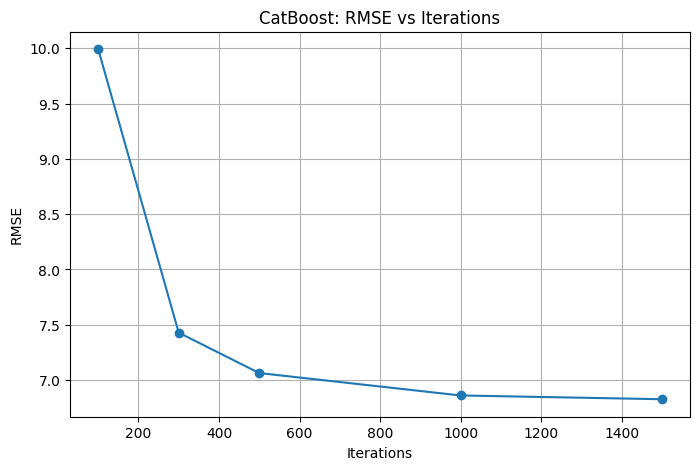

,rmse,mae,r2
iterations,,,
100,9.991774,5.648450,0.979380
300,7.428014,3.833856,0.988604
500,7.062795,3.463859,0.989697
1000,6.860150,3.200024,0.990280
1500,6.826185,3.147469,0.990376


In [5]:
iterations_list = [100, 300, 500, 1000, 1500]
results_iter = []

for n in iterations_list:
    model = CatBoostRegressor(
        iterations=n,
        learning_rate=0.05,
        depth=10,
        loss_function='RMSE',
        verbose=0,
        random_seed=42
    )
    r = run_and_record(model, f"CB_iterations_{n}", all_results)
    results_iter.append(r)

# Build DataFrame for plotting
df_iter = pd.DataFrame([{
    "iterations": r['model'].get_params()['iterations'],
    **r['metrics']
} for r in results_iter])

plt.figure(figsize=(8,5))
plt.plot(df_iter['iterations'], df_iter['rmse'], marker='o')
plt.xlabel('Iterations')
plt.ylabel('RMSE')
plt.title('CatBoost: RMSE vs Iterations')
plt.grid(True)
plt.savefig('cb_iterations_sweep.png')
plt.show()

# Show table
display(df_iter.set_index('iterations'))

Running: CB_depth_4...
Running: CB_depth_6...
Running: CB_depth_8...
Running: CB_depth_10...
Running: CB_depth_12...


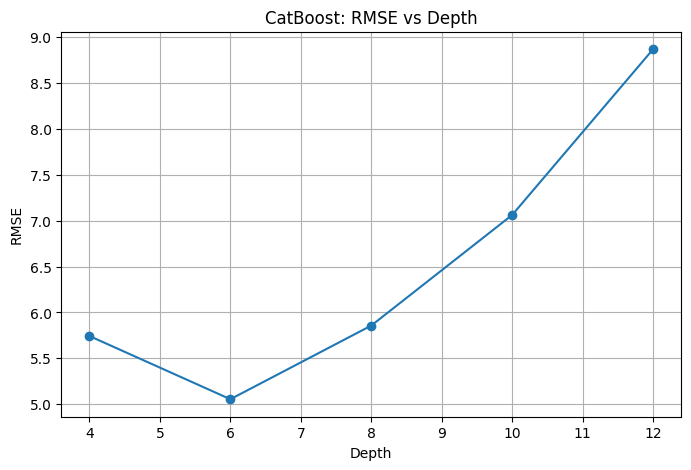

,rmse,mae,r2
depth,,,
4,5.743108,3.223240,0.993188
6,5.054249,2.844749,0.994724
8,5.857110,3.057479,0.992915
10,7.062795,3.463859,0.989697
12,8.869302,4.310372,0.983753


In [6]:
depth_list = [4, 6, 8, 10, 12]
results_depth = []

for d in depth_list:
    model = CatBoostRegressor(
        iterations=500,
        learning_rate=0.05,
        depth=d,
        loss_function='RMSE',
        verbose=0,
        random_seed=42
    )
    r = run_and_record(model, f"CB_depth_{d}", all_results)
    results_depth.append(r)

# Build DataFrame for plotting
df_depth = pd.DataFrame([{
    "depth": r['model'].get_params()['depth'],
    **r['metrics']
} for r in results_depth])

plt.figure(figsize=(8,5))
plt.plot(df_depth['depth'], df_depth['rmse'], marker='o')
plt.xlabel('Depth')
plt.ylabel('RMSE')
plt.title('CatBoost: RMSE vs Depth')
plt.grid(True)
plt.savefig('cb_depth_sweep.png')
plt.show()

# Show table
display(df_depth.set_index('depth'))

Running: CB_lr_0.01...
Running: CB_lr_0.03...
Running: CB_lr_0.05...
Running: CB_lr_0.1...
Running: CB_lr_0.2...


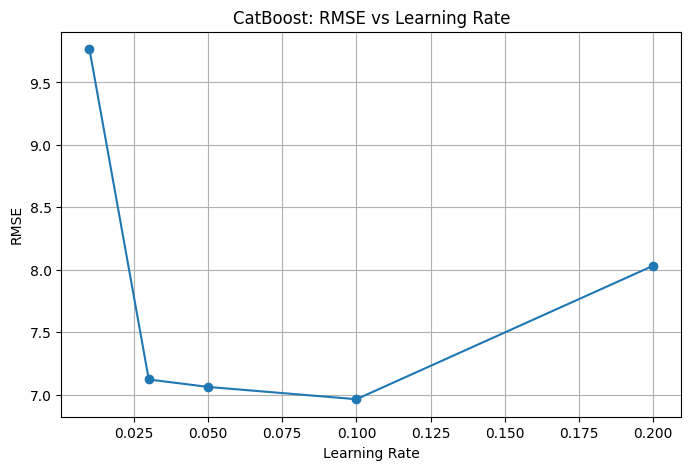

,rmse,mae,r2
learning_rate,,,
0.01,9.765713,5.557593,0.980303
0.03,7.122423,3.693117,0.989523
0.05,7.062795,3.463859,0.989697
0.10,6.964434,3.516272,0.989982
0.20,8.032665,4.178725,0.986673


In [7]:
learning_rate_list = [0.01, 0.03, 0.05, 0.1, 0.2]
results_lr = []

for lr in learning_rate_list:
    model = CatBoostRegressor(
        iterations=500,
        learning_rate=lr,
        depth=10,
        loss_function='RMSE',
        verbose=0,
        random_seed=42
    )
    r = run_and_record(model, f"CB_lr_{lr}", all_results)
    results_lr.append(r)

# Build DataFrame for plotting
df_lr = pd.DataFrame([{
    "learning_rate": r['model'].get_params()['learning_rate'],
    **r['metrics']
} for r in results_lr])

plt.figure(figsize=(8,5))
plt.plot(df_lr['learning_rate'], df_lr['rmse'], marker='o')
plt.xlabel('Learning Rate')
plt.ylabel('RMSE')
plt.title('CatBoost: RMSE vs Learning Rate')
plt.grid(True)
plt.savefig('cb_learning_rate_sweep.png')
plt.show()

# Show table
display(df_lr.set_index('learning_rate'))

Running: CB_l2_leaf_reg_1...
Running: CB_l2_leaf_reg_3...
Running: CB_l2_leaf_reg_5...
Running: CB_l2_leaf_reg_10...
Running: CB_l2_leaf_reg_20...


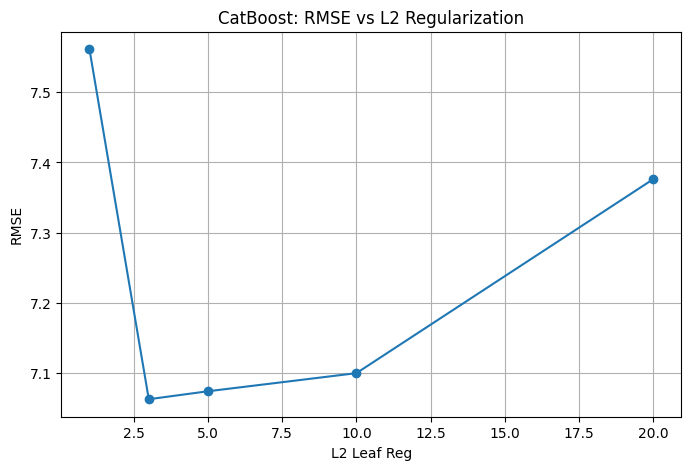

,rmse,mae,r2
l2_leaf_reg,,,
1,7.561356,3.433147,0.988191
3,7.062795,3.463859,0.989697
5,7.074170,3.537087,0.989664
10,7.099943,3.846382,0.989589
20,7.376134,4.192395,0.988763


In [8]:
l2_list = [1, 3, 5, 10, 20]
results_l2 = []

for l2 in l2_list:
    model = CatBoostRegressor(
        iterations=500,
        learning_rate=0.05,
        depth=10,
        l2_leaf_reg=l2,
        loss_function='RMSE',
        verbose=0,
        random_seed=42
    )
    r = run_and_record(model, f"CB_l2_leaf_reg_{l2}", all_results)
    results_l2.append(r)

# Build DataFrame for plotting
df_l2 = pd.DataFrame([{
    "l2_leaf_reg": r['model'].get_params()['l2_leaf_reg'],
    **r['metrics']
} for r in results_l2])

plt.figure(figsize=(8,5))
plt.plot(df_l2['l2_leaf_reg'], df_l2['rmse'], marker='o')
plt.xlabel('L2 Leaf Reg')
plt.ylabel('RMSE')
plt.title('CatBoost: RMSE vs L2 Regularization')
plt.grid(True)
plt.savefig('cb_l2_leaf_reg_sweep.png')
plt.show()

# Show table
display(df_l2.set_index('l2_leaf_reg'))

Running: CB_subsample_0.6...
Running: CB_subsample_0.8...
Running: CB_subsample_1.0...


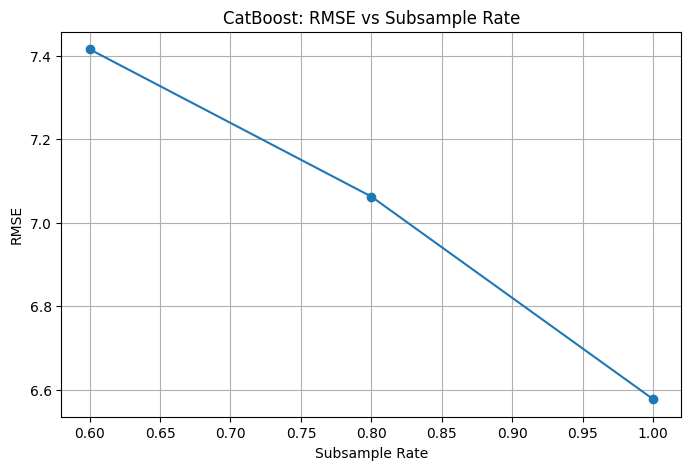

,rmse,mae,r2
subsample,,,
0.6,7.415916,3.553929,0.988641
0.8,7.062795,3.463859,0.989697
1.0,6.577364,3.449749,0.991065


In [9]:
subsample_list = [0.6, 0.8, 1.0] # 1.0 means no subsampling
results_sub = []

for s in subsample_list:
    model = CatBoostRegressor(
        iterations=500,
        learning_rate=0.05,
        depth=10,
        subsample=s,
        loss_function='RMSE',
        verbose=0,
        random_seed=42
    )
    r = run_and_record(model, f"CB_subsample_{s}", all_results)
    results_sub.append(r)

# Build DataFrame for plotting
df_sub = pd.DataFrame([{
    "subsample": r['model'].get_params()['subsample'],
    **r['metrics']
} for r in results_sub])

plt.figure(figsize=(8,5))
plt.plot(df_sub['subsample'], df_sub['rmse'], marker='o')
plt.xlabel('Subsample Rate')
plt.ylabel('RMSE')
plt.title('CatBoost: RMSE vs Subsample Rate')
plt.grid(True)
plt.savefig('cb_subsample_sweep.png')
plt.show()

# Show table
display(df_sub.set_index('subsample'))

In [10]:
summary_rows = []
for r in all_results:
    params = r['model'].get_params()
    summary_rows.append({
        'name': r['name'],
        'iterations': params.get('iterations'),
        'depth': params.get('depth'),
        'learning_rate': params.get('learning_rate'),
        'l2_leaf_reg': params.get('l2_leaf_reg'),
        'subsample': params.get('subsample'),
        'rmse': r['metrics']['rmse'],
        'mae': r['metrics']['mae'],
        'r2': r['metrics']['r2'],
        'train_time_s': r['train_time']
    })

df_summary = pd.DataFrame(summary_rows).sort_values('rmse')

# Show top 10 best runs
print("Top 10 performing CatBoost models by RMSE:")
display(df_summary.head(10))

# Save summary to CSV
try:
    df_summary.to_csv('catboost_parameter_sweep_summary.csv', index=False)
    print('\nSaved summary to catboost_parameter_sweep_summary.csv')
except Exception as e:
    print(f'Could not save summary CSV: {e}')

Top 10 performing CatBoost models by RMSE:


,name,iterations,depth,learning_rate,l2_leaf_reg,subsample,rmse,mae,r2,train_time_s
7,CB_depth_6,500,6,0.05,NaN,NaN,5.054249,2.844749,0.994724,2.212999
6,CB_depth_4,500,4,0.05,NaN,NaN,5.743108,3.223240,0.993188,1.003501
8,CB_depth_8,500,8,0.05,NaN,NaN,5.857110,3.057479,0.992915,7.628465
23,CB_subsample_1.0,500,10,0.05,NaN,1.0,6.577364,3.449749,0.991065,23.109033
5,CB_iterations_1500,1500,10,0.05,NaN,NaN,6.826185,3.147469,0.990376,71.063247
4,CB_iterations_1000,1000,10,0.05,NaN,NaN,6.860150,3.200024,0.990280,47.047073
14,CB_lr_0.1,500,10,0.10,NaN,NaN,6.964434,3.516272,0.989982,23.211186
3,CB_iterations_500,500,10,0.05,NaN,NaN,7.062795,3.463859,0.989697,23.066392
13,CB_lr_0.05,500,10,0.05,NaN,NaN,7.062795,3.463859,0.989697,23.449899
9,CB_depth_10,500,10,0.05,NaN,NaN,7.062795,3.463859,0.989697,23.115230



Saved summary to catboost_parameter_sweep_summary.csv
